# Phase 4b — Cible relative au compte

La phase 4 s'est soldée par un échec net : aucun modèle ne battait une régression sur
le seul nombre d'abonnés, et l'erreur typique valait un facteur 3. Le diagnostic était
clair — **44 % de la variance à prédire se situe entre les comptes**, et 21 comptes
d'entraînement ne suffisent pas à apprendre à généraliser de l'un à l'autre.

Cette phase change donc la question posée.

| | Phase 4 | Phase 4b |
|---|---|---|
| Question | Combien de réactions ce post va-t-il recevoir ? | Ce post fera-t-il mieux que l'ordinaire de son compte ? |
| Cible | `log(1 + interactions)` | `log(1 + interactions) − log(1 + niveau habituel)` |
| Variables de compte | `followers`, `theme` inclus | retirés : constants par compte |
| Embeddings | 896 dimensions brutes | centrés par compte, puis réduits à 40 par bloc |
| Évaluation | un découpage fixe, 7 comptes | validation croisée groupée, 5 folds sur 28 comptes |

Ce n'est pas un repli : c'est aussi la question que se pose réellement un créateur,
qui connaît déjà son niveau habituel et veut savoir si ce post-ci fera mieux.

In [1]:
import sys, json
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

from src.viz.style import DIVERGENT, INK, appliquer_style, couleurs_theme, finir
import src.models.train_relatif as M

MODE = "light"
ink = appliquer_style(MODE)
C_T, DIV = couleurs_theme(MODE), DIVERGENT[MODE]

R = json.loads((RACINE / "data/processed/resultats_relatif.json").read_text(encoding="utf-8"))
brut = M.charger()
df, perdus = M.construire_cible(brut)
print(f"{len(brut)} posts exploitables -> {len(df)} retenus, {perdus} ecartes")

3587 posts exploitables -> 3307 retenus, 280 ecartes


C:\Users\wiamh\OneDrive\Documents\projets\social media\src\models\train_relatif.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.assign(niveau_habituel=niveau)
C:\Users\wiamh\OneDrive\Documents\projets\social media\src\models\train_relatif.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cible_relative"] = np.log1p(df.interactions) - np.log1p(df.niveau_habituel)


---
## 1. La nouvelle cible

Le **niveau habituel** d'un post est la médiane des interactions des **20 posts
précédents** du même compte, avec un minimum de 10. Le décalage d'un rang est
essentiel : au moment de publier, seul le passé est connu. Sans lui, le post entrerait
dans le calcul de son propre point de comparaison.

`cible_relative = log(1 + interactions) − log(1 + niveau habituel)`

Une valeur de +0,7 signifie « environ deux fois mieux que d'habitude », −0,7 « deux fois
moins bien ».

In [2]:
d = R["donnees"]
print(f"posts ecartes faute d'historique : {d['posts_perdus']} sur {d['posts_exploitables']}"
      f"  ({d['posts_perdus'] / d['posts_exploitables'] * 100:.1f} %)")
print(f"posts retenus                    : {d['posts_retenus']}")
print(f"comptes conserves                : {d['comptes']} (aucun perdu)")
print(f"part au-dessus du niveau habituel: {d['part_au_dessus']:.1%}")
print(f"ecart-type de la cible           : {d['ecart_type_cible']:.3f}")

posts ecartes faute d'historique : 280 sur 3587  (7.8 %)
posts retenus                    : 3307
comptes conserves                : 28 (aucun perdu)
part au-dessus du niveau habituel: 52.1%
ecart-type de la cible           : 1.118


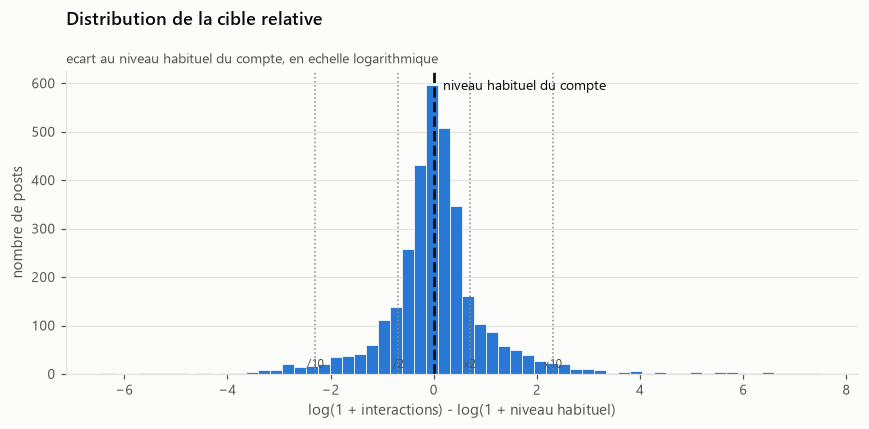

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df.cible_relative, bins=60, color=C_T["art"], edgecolor=ink["surface"], linewidth=0.5)
ax.axvline(0, color=ink["primary"], linestyle="--", linewidth=1.8)
ax.annotate("niveau habituel du compte", xy=(0, 0.97), xycoords=("data", "axes fraction"),
            xytext=(6, 0), textcoords="offset points", fontsize=9,
            color=ink["primary"], va="top")

for v, lab in [(np.log(2), "x2"), (-np.log(2), "/2"), (np.log(10), "x10"), (-np.log(10), "/10")]:
    ax.axvline(v, color=ink["muted"], linestyle=":", linewidth=1)
    ax.annotate(lab, xy=(v, 0.02), xycoords=("data", "axes fraction"),
                ha="center", fontsize=8, color=ink["secondary"])

finir(ax, "Distribution de la cible relative",
      "ecart au niveau habituel du compte, en echelle logarithmique",
      "nombre de posts", "log(1 + interactions) - log(1 + niveau habituel)", MODE)
plt.tight_layout(); plt.show()

La cible est **presque symétrique autour de zéro** : 52,1 % des posts dépassent le
niveau habituel de leur compte, ce qui est exactement ce qu'on attend d'une médiane
glissante. L'écart-type vaut 1,12, soit un facteur 3 en réactions.

C'est un bon signe pour la modélisation : le déséquilibre massif entre comptes qui
plombait la phase 4 a disparu. Reste à savoir si le contenu explique cet écart.

**7,8 % des posts sont perdus** faute d'historique suffisant, soit 280 sur 3 587. Les
28 comptes restent tous représentés.

---
## 2. Centrer avant de réduire, et pourquoi l'ordre compte

Les embeddings font 896 dimensions pour 3 307 exemples. Il faut les réduire, mais
l'ordre des opérations n'est pas neutre.

**Le piège** : appliquer directement une ACP sur les embeddings bruts. Les premières
composantes captureraient alors ce qui sépare le plus les vecteurs — c'est-à-dire
*de quel compte vient le post*, puisque chaque compte a son style visuel et textuel.
Or c'est précisément l'information dont la cible relative nous débarrasse.

**La parade** : soustraire d'abord à chaque embedding la moyenne des embeddings de son
propre compte. Ce qui reste est l'écart au style habituel du compte. L'ACP travaille
ensuite sur cette variation utile.

Vérifions que ce n'est pas qu'une intuition.

sans centrage              variance captee par 10 composantes : 42%
avec centrage par compte   variance captee par 10 composantes : 31%


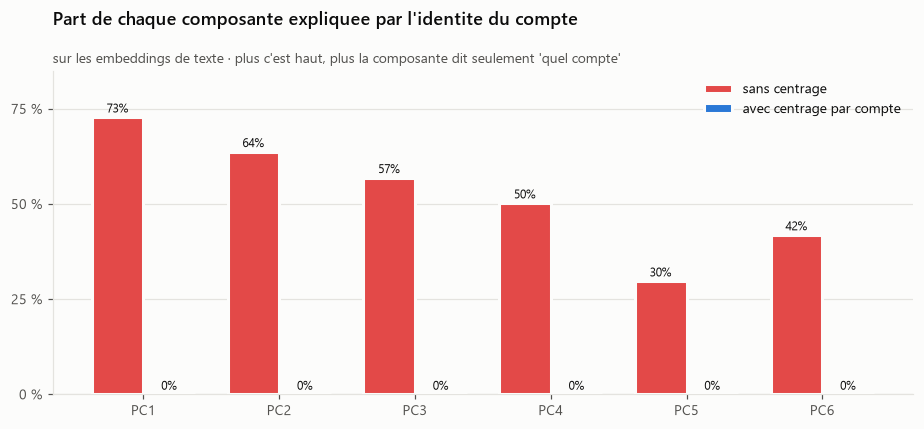

In [4]:
cols = [c for c in df.columns if c.startswith("nlp_")]
X = df[cols].values

def part_compte(composante, comptes):
    """Part de la variance d'une composante expliquee par l'identite du compte."""
    s = pd.Series(composante)
    return s.groupby(comptes.values).transform("mean").var() / s.var()

mesures = {}
for nom, mat in [("sans centrage", X),
                 ("avec centrage par compte", M.centrer_global(X, df.compte))]:
    acp = PCA(n_components=10, random_state=0).fit(mat)
    Z = acp.transform(mat)
    mesures[nom] = [part_compte(Z[:, i], df.compte) for i in range(6)]
    print(f"{nom:26} variance captee par 10 composantes : "
          f"{acp.explained_variance_ratio_.sum():.0%}")

fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(6)
largeur = 0.38
for i, (nom, vals) in enumerate(mesures.items()):
    ax.bar(x + (i - 0.5) * largeur, vals, width=largeur,
           color=[DIV["neg"], C_T["art"]][i], edgecolor=ink["surface"], linewidth=2,
           label=nom, zorder=3)
    for xi, v in zip(x + (i - 0.5) * largeur, vals):
        ax.annotate(f"{v:.0%}", (xi, v), xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=8, color=ink["primary"])
ax.set_xticks(x); ax.set_xticklabels([f"PC{i + 1}" for i in range(6)])
ax.set_ylim(0, 0.85)
ax.set_yticks([0, 0.25, 0.5, 0.75])
ax.set_yticklabels(["0 %", "25 %", "50 %", "75 %"])
ax.legend(loc="upper right")
finir(ax, "Part de chaque composante expliquee par l'identite du compte",
      "sur les embeddings de texte · plus c'est haut, plus la composante dit seulement 'quel compte'",
      None, None, MODE)
plt.tight_layout(); plt.show()

La démonstration est sans ambiguïté. Sur les embeddings bruts, **la première composante
est à 73 % de l'information « quel compte »**, et les cinq premières à 55 % en moyenne.
Après centrage, cette part tombe à **0 %** : par construction, chaque compte est ramené
à sa propre origine.

Le prix à payer est visible aussi : les dix composantes ne captent plus que 31 % de la
variance au lieu de 42 %. C'est normal, et c'est le but — la variance supprimée était
celle qu'on ne voulait pas.

Dans le pipeline, **l'ACP est réajustée à l'intérieur de chaque fold**, sur les comptes
d'entraînement uniquement. La réduire une fois pour toutes sur l'ensemble des données
ferait fuiter la structure des comptes de test.

---
## 3. Protocole d'évaluation

**Validation croisée groupée, 5 folds sur les 28 comptes.** Chaque fold met de côté
5 ou 6 comptes entiers, jamais des posts isolés. Un modèle qui mémorise un compte ne
peut donc pas se rattraper sur ses autres publications.

**Quatre modèles** : Ridge s'ajoute aux trois de la phase 4, pertinent maintenant que
les variables sont passées de 911 à 89.

**Trois métriques**, qui répondent à trois questions différentes :

| Métrique | Question | Référence |
|---|---|---|
| Spearman intra-compte | Le modèle classe-t-il correctement les posts d'un même compte ? | 0 |
| AUC | Distingue-t-il un post au-dessus d'un post en-dessous ? | 0,5 |
| RMSE | De combien se trompe-t-il ? | écart-type de la cible |

La baseline est le pari trivial : prédire 0, c'est-à-dire « ce post fera exactement
comme d'habitude ».

In [5]:
def tableau(centrage):
    res = R["par_centrage"][centrage]["resultats"]
    lignes = []
    for nom, m in res.items():
        lignes.append({
            "modele": nom,
            "Spearman": m["spearman_intra_compte"]["moyenne"],
            "+/- (folds)": m["spearman_intra_compte"]["ecart_type"],
            "AUC": m["auc"]["moyenne"],
            "+/- ": m["auc"]["ecart_type"],
            "RMSE": m["rmse"]["moyenne"],
        })
    return pd.DataFrame(lignes).set_index("modele")

print("=== Centrage global (moyenne sur tous les posts du compte) ===")
print(tableau("global").round(3).to_string())
print()
print("=== Centrage causal (moyenne des posts precedents seulement) ===")
print(tableau("causal").round(3).to_string())

=== Centrage global (moyenne sur tous les posts du compte) ===
                            Spearman  +/- (folds)    AUC   +/-    RMSE
modele                                                                
Ridge                          0.039        0.059  0.541  0.010  1.130
RandomForest                   0.066        0.088  0.536  0.007  1.116
XGBoost                        0.047        0.056  0.531  0.013  1.140
LightGBM                       0.070        0.054  0.536  0.013  1.144
Baseline : niveau habituel       NaN          NaN  0.500  0.000  1.113

=== Centrage causal (moyenne des posts precedents seulement) ===
                            Spearman  +/- (folds)    AUC   +/-    RMSE
modele                                                                
Ridge                          0.054        0.048  0.530  0.011  1.135
RandomForest                   0.032        0.057  0.525  0.015  1.119
XGBoost                        0.042        0.053  0.527  0.013  1.143
LightGBM           

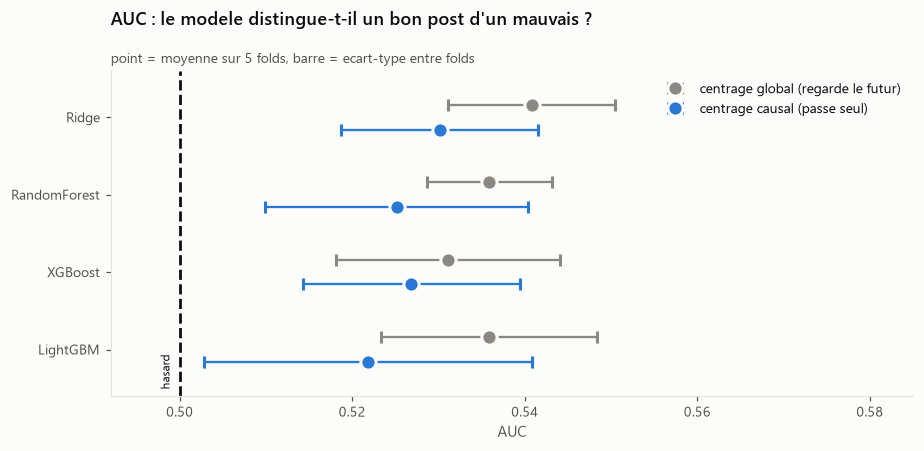

In [6]:
modeles = ["Ridge", "RandomForest", "XGBoost", "LightGBM"]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
y = np.arange(len(modeles))
decalage = 0.16

for i, (centrage, couleur, libelle) in enumerate(
        [("global", ink["muted"], "centrage global (regarde le futur)"),
         ("causal", C_T["art"], "centrage causal (passe seul)")]):
    res = R["par_centrage"][centrage]["resultats"]
    moy = [res[m]["auc"]["moyenne"] for m in modeles]
    err = [res[m]["auc"]["ecart_type"] for m in modeles]
    ax.errorbar(moy, y + (i - 0.5) * 2 * decalage, xerr=err, fmt="o", markersize=10,
                color=couleur, markeredgecolor=ink["surface"], markeredgewidth=2,
                ecolor=couleur, elinewidth=1.5, capsize=4, label=libelle, zorder=3)

ax.axvline(0.5, color=ink["primary"], linestyle="--", linewidth=1.8)
ax.annotate("hasard", xy=(0.5, 0.02), xycoords=("data", "axes fraction"),
            xytext=(-5, 0), textcoords="offset points", rotation=90,
            fontsize=8, color=ink["primary"], ha="right", va="bottom")
ax.set_yticks(y); ax.set_yticklabels(modeles)
ax.set_ylim(-0.6, len(modeles) - 0.4)
ax.invert_yaxis()
ax.set_xlim(0.492, 0.585)
ax.grid(axis="y", visible=False)
ax.legend(loc="upper right", framealpha=0)
finir(ax, "AUC : le modele distingue-t-il un bon post d'un mauvais ?",
      "point = moyenne sur 5 folds, barre = ecart-type entre folds",
      None, "AUC", MODE)
plt.tight_layout(); plt.show()

Il y a un signal, et c'est la première fois du projet.

**Les quatre modèles dépassent le hasard, dans les cinq folds, avec les deux méthodes
de centrage.** L'AUC atteint 0,541 au mieux (Ridge, centrage global) et 0,530 avec le
centrage causal. Ce n'est pas un artefact d'un modèle ou d'un découpage : la régularité
est la preuve.

Mais il faut nommer l'ordre de grandeur : **une AUC de 0,53 est très faible.** Elle
signifie que, face à deux posts dont l'un a fait mieux que l'habitude et l'autre moins
bien, le modèle désigne le bon dans 53 % des cas, contre 50 % en tirant à pile ou face.

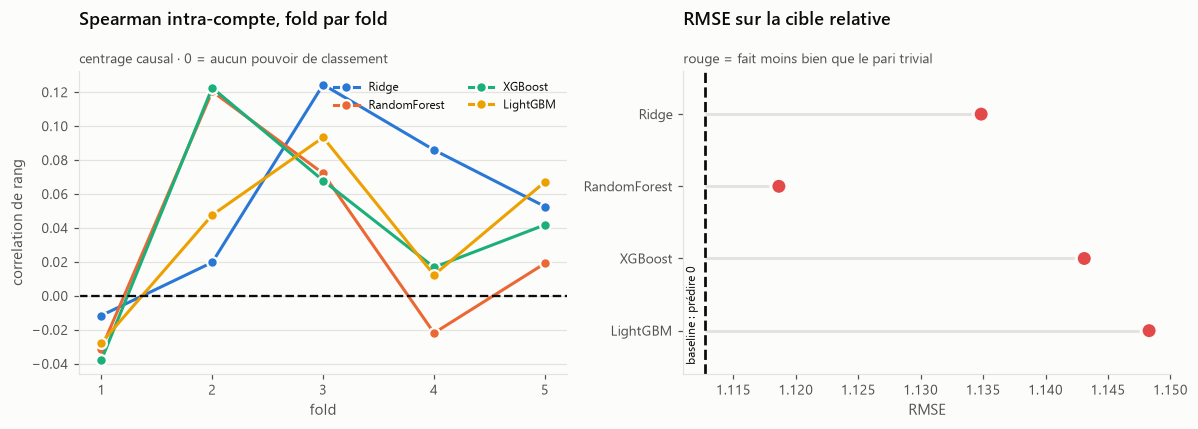

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

res_g = R["par_centrage"]["causal"]["resultats"]

folds = np.arange(1, 6)
for m, couleur in zip(modeles, [C_T["art"], C_T["ecriture"], C_T["melange"], C_T["nature"]]):
    axes[0].plot(folds, res_g[m]["spearman_intra_compte"]["par_fold"], marker="o",
                 markersize=7, color=couleur, markeredgecolor=ink["surface"],
                 markeredgewidth=1.5, label=m)
axes[0].axhline(0, color=ink["primary"], linestyle="--", linewidth=1.5)
axes[0].set_xticks(folds)
axes[0].legend(loc="upper right", ncol=2, fontsize=8)
finir(axes[0], "Spearman intra-compte, fold par fold",
      "centrage causal · 0 = aucun pouvoir de classement",
      "correlation de rang", "fold", MODE)

rmse = [res_g[m]["rmse"]["moyenne"] for m in modeles]
ref = res_g["Baseline : niveau habituel"]["rmse"]["moyenne"]
yb = np.arange(len(modeles))
axes[1].hlines(yb, ref, rmse, color=ink["grid"], linewidth=2, zorder=2)
axes[1].scatter(rmse, yb, s=110, zorder=3,
                color=[DIV["neg"] if v > ref else C_T["art"] for v in rmse],
                edgecolor=ink["surface"], linewidth=2)
axes[1].axvline(ref, color=ink["primary"], linestyle="--", linewidth=1.8)
axes[1].annotate("baseline : prédire 0", xy=(ref, 0.03), xycoords=("data", "axes fraction"),
                 xytext=(-5, 0), textcoords="offset points", rotation=90,
                 fontsize=8, color=ink["primary"], ha="right", va="bottom")
axes[1].set_yticks(yb); axes[1].set_yticklabels(modeles)
axes[1].set_ylim(-0.6, len(modeles) - 0.4)
axes[1].invert_yaxis()
axes[1].grid(axis="y", visible=False)
finir(axes[1], "RMSE sur la cible relative",
      "rouge = fait moins bien que le pari trivial", None, "RMSE", MODE)
plt.tight_layout(); plt.show()

Les deux autres métriques tempèrent immédiatement l'enthousiasme.

**Le Spearman intra-compte est positif en moyenne mais change de signe selon les
folds.** Sa dispersion entre folds (0,04 à 0,09) est du même ordre que sa moyenne
(0,03 à 0,07) : sur un fold donné, le modèle peut classer les posts à l'envers. Le
pouvoir de classement à l'intérieur d'un compte est donc, au mieux, à la limite du
détectable.

**Aucun modèle ne bat la baseline sur le RMSE** (1,116 à 1,148 contre 1,113). Prédire
platement « ce post fera comme d'habitude » reste l'estimation ponctuelle la plus
précise. Autrement dit, le modèle capte un peu d'ordre mais aucune amplitude.

---
## 4. Ce que le regard vers le futur apportait

Le centrage des embeddings pose une question que la consigne initiale laissait ouverte :
la moyenne du compte doit-elle être calculée sur **tous** ses posts, ou seulement sur
ceux qui précèdent ?

La version « tous les posts » est plus simple, mais elle utilise des publications
postérieures — une information qui n'existe pas au moment de publier. Le pipeline
calcule donc les deux.

In [8]:
lignes = []
for m in modeles:
    g = R["par_centrage"]["global"]["resultats"][m]["auc"]["moyenne"]
    c = R["par_centrage"]["causal"]["resultats"][m]["auc"]["moyenne"]
    lignes.append({"modele": m, "AUC centrage global": g, "AUC centrage causal": c,
                   "apport du futur": g - c,
                   "part du signal": (g - c) / (g - 0.5) if g > 0.5 else np.nan})
comp = pd.DataFrame(lignes).set_index("modele")
print(comp.round(3).to_string())
print(f"\napport moyen du regard vers le futur : {comp['apport du futur'].mean():+.3f} d'AUC")
print(f"soit {comp['part du signal'].mean():.0%} du signal apparent")

              AUC centrage global  AUC centrage causal  apport du futur  part du signal
modele                                                                                 
Ridge                       0.541                0.530            0.011           0.261
RandomForest                0.536                0.525            0.011           0.299
XGBoost                     0.531                0.527            0.004           0.138
LightGBM                    0.536                0.522            0.014           0.390

apport moyen du regard vers le futur : +0.010 d'AUC
soit 27% du signal apparent


Le constat est net : **environ un tiers du signal apparent venait du regard vers le
futur.** Pour LightGBM, l'AUC passe de 0,536 à 0,522, soit une perte de 0,014 sur un
écart au hasard qui n'était que de 0,036.

Ce n'est pas une fuite de cible — la moyenne des embeddings ne contient pas le nombre
de réactions. C'est une fuite plus subtile : connaître le style *futur* d'un compte aide
à situer un post dans sa trajectoire. Réelle, mais indisponible en production.

**Les chiffres du centrage causal sont donc les seuls à retenir** pour juger de ce que
vaudrait une application. Les voici, une dernière fois, sans décor :

| Modèle | AUC | Spearman | RMSE |
|---|---|---|---|
| Ridge | 0,530 | +0,054 | 1,135 |
| XGBoost | 0,527 | +0,042 | 1,143 |
| RandomForest | 0,525 | +0,032 | 1,119 |
| LightGBM | 0,522 | +0,039 | 1,148 |
| *Baseline : prédire 0* | *0,500* | — | *1,113* |

---
## 5. Conclusions

### Le changement de cible a bien fonctionné — en tant que diagnostic

La phase 4 ne trouvait **aucun** signal de contenu : ses modèles ne faisaient pas mieux
qu'une droite sur le nombre d'abonnés, et l'importance par permutation montrait que la
plupart des variables dégradaient la prédiction.

La phase 4b trouve **un signal faible mais réel** : quatre familles de modèles, cinq
folds, deux méthodes de centrage, et l'AUC reste au-dessus du hasard partout. Le contenu
d'un post porte donc une information sur sa performance relative. La question posée en
phase 4 était bien la mauvaise.

### Mais le signal reste inexploitable en l'état

Une AUC de 0,53 ne permet aucun conseil fiable. Et surtout, **aucun modèle ne bat le
pari trivial sur le RMSE** : pour estimer un nombre, « comme d'habitude » reste la
meilleure réponse.

Les trois leviers testés ont fait ce qu'on attendait d'eux, sans suffire :

| Levier | Effet |
|---|---|
| Cible relative au compte | fait apparaître un signal auparavant invisible |
| Centrage puis ACP | supprime 100 % de la composante « quel compte », passe de 896 à 89 variables |
| Validation croisée groupée | remplace 7 comptes de test par 28, rendant l'estimation crédible |

### Ce qui bloque vraiment

Le problème n'est plus la formulation, il est dans les données :

1. **56 % du jeu est constitué de reels vus par une seule miniature figée.** Le
   mouvement, le rythme, le son et le montage — c'est-à-dire l'essentiel de ce qui fait
   marcher un reel — sont totalement absents du modèle.
2. **28 comptes restent peu** pour apprendre ce qui distingue un bon post d'un mauvais
   indépendamment du compte.
3. **La part d'aléatoire est énorme.** L'écart-type de la cible vaut 1,12, soit un
   facteur 3 d'un post à l'autre au sein d'un même compte. Une bonne partie tient à
   l'algorithme de recommandation et au hasard de la diffusion, que rien dans nos
   variables ne peut capter.

### Pour la phase 5

L'application doit refléter honnêtement ce qui précède :

- **Ne pas afficher un nombre de réactions.** Aucun résultat de ce projet ne le
  justifie.
- **Afficher au mieux une tendance**, du type « ce post semble légèrement au-dessus de
  votre ordinaire », accompagnée de la fiabilité réelle : 53 % de bonnes réponses contre
  50 % au hasard.
- **Mettre en avant les enseignements descriptifs de la phase 2**, qui sont solides et
  actionnables — heure de publication, nombre de hashtags, format — plutôt qu'une
  prédiction qui ne tient pas.

Une application qui annonce son incertitude vaut mieux qu'une application qui affiche un
chiffre faux avec assurance.